In [1]:
# Install PyTorch Geometric
!pip install torch_geometric

import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

BASE_PATH = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project' 

# Load the Graph Edges and Vocabulary
with open(os.path.join(BASE_PATH, 'skill_vocab.json'), 'r') as f:
    skill_vocab = json.load(f)

with open(os.path.join(BASE_PATH, 'graph_edges.json'), 'r') as f:
    graph_edges = json.load(f)

print(f"Loaded {len(skill_vocab)} skills and {len(graph_edges)} edges.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00a 0:00:01
Loaded 500 skills and 241244 edges.


In [2]:
# 1. Map skills to integer IDs
skill_to_id = {skill: i for i, skill in enumerate(skill_vocab)}
id_to_skill = {i: skill for skill, i in skill_to_id.items()}
num_nodes = len(skill_vocab)

# 2. Build edge lists
source_nodes = []
target_nodes = []
edge_weights = []

# To prevent dominating weights, we will apply a log transform to the counts
for edge in graph_edges:
    skill1, skill2, weight = edge['source'], edge['target'], edge['weight']
    
    if skill1 in skill_to_id and skill2 in skill_to_id:
        id1 = skill_to_id[skill1]
        id2 = skill_to_id[skill2]
        
        # PyG expects directed edges. For an undirected graph, add both directions.
        source_nodes.extend([id1, id2])
        target_nodes.extend([id2, id1])
        
        # Log-normalize weights so massive counts (like 5000) don't explode the gradients
        norm_weight = np.log1p(weight)
        edge_weights.extend([norm_weight, norm_weight])

# 3. Convert to PyTorch Tensors
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
edge_weight = torch.tensor(edge_weights, dtype=torch.float)

# 4. Node Features (X)
# Since we are learning embeddings from scratch, our initial node features 
# are just their integer IDs. We will pass these into an nn.Embedding layer later.
x = torch.arange(num_nodes, dtype=torch.long)

# 5. Create the PyG Data Object
graph_data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight)

# Move to GPU 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph_data = graph_data.to(device)

print(f"Graph created on {device}!")
print(f"Nodes: {graph_data.num_nodes}")
print(f"Edges: {graph_data.num_edges}")

Graph created on cuda!
Nodes: 500
Edges: 181810


## Define GAT

In [3]:
from torch_geometric.nn import GATConv

class SkillGAT(nn.Module):
    def __init__(self, num_nodes, embedding_dim=128):
        super(SkillGAT, self).__init__()
        
        # 1. Base Embedding Layer: Translates Skill ID to a dense 128-dim vector
        self.node_emb = nn.Embedding(num_nodes, embedding_dim)
        
        # 2. First GAT Layer: 4 attention heads to capture different types of relationships
        # output will be 128 dim (32 * 4 heads)
        self.gat1 = GATConv(in_channels=embedding_dim, out_channels=32, heads=4, dropout=0.1)
        
        # 3. Second GAT Layer: Condense back to 128-dim
        self.gat2 = GATConv(in_channels=128, out_channels=embedding_dim, heads=1, dropout=0.1)

    def forward(self, x, edge_index, edge_weight):
        # Step A: Get initial base embeddings
        emb = self.node_emb(x)
        
        # Step B: First round of Message Passing (Graph Convolution)
        # Skills "look" at their neighbors and update their meaning
        h = self.gat1(emb, edge_index, edge_attr=edge_weight)
        h = F.elu(h)
        h = F.dropout(h, p=0.1, training=self.training)
        
        # Step C: Second round of Message Passing
        out_emb = self.gat2(h, edge_index, edge_attr=edge_weight)
        
        return out_emb # These are the final, context-aware skill embeddings!

# Initialize the model
embedding_dim = 128
model = SkillGAT(num_nodes=num_nodes, embedding_dim=embedding_dim).to(device)

print("Model Architecture:")
print(model)

Model Architecture:
SkillGAT(
  (node_emb): Embedding(500, 128)
  (gat1): GATConv(128, 32, heads=4)
  (gat2): GATConv(128, 128, heads=1)
)


## Training Loop(Link Prediction)
To train a graph that has no labels -> we use link prediction

Starting GNN Pre-training (Link Prediction)...
Epoch: 010, Loss: 1.4073, AUC: 0.6947
Epoch: 020, Loss: 1.3884, AUC: 0.8080
Epoch: 030, Loss: 1.3848, AUC: 0.8228
Epoch: 040, Loss: 1.3801, AUC: 0.8136
Epoch: 050, Loss: 1.3646, AUC: 0.8151
Epoch: 060, Loss: 1.2644, AUC: 0.7609
Epoch: 070, Loss: 1.4174, AUC: 0.6017
Epoch: 080, Loss: 1.2441, AUC: 0.7511
Epoch: 090, Loss: 1.2101, AUC: 0.7973
Epoch: 100, Loss: 1.1952, AUC: 0.7893
Epoch: 110, Loss: 1.1644, AUC: 0.7845
Epoch: 120, Loss: 1.1572, AUC: 0.7787
Epoch: 130, Loss: 1.1699, AUC: 0.7754
Epoch: 140, Loss: 1.1556, AUC: 0.7981
Epoch: 150, Loss: 1.1493, AUC: 0.7850


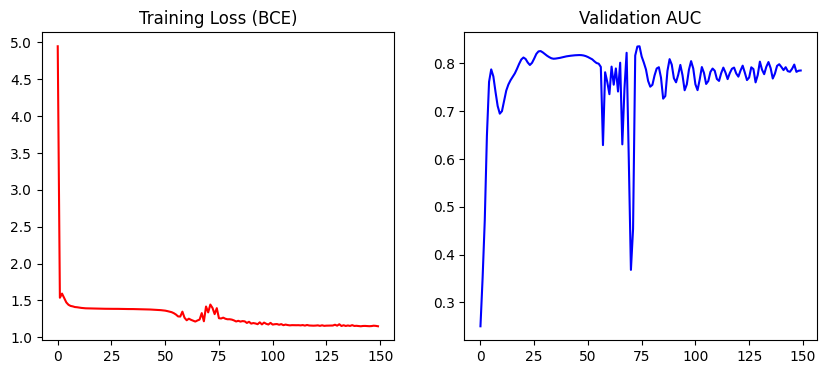

In [4]:
from torch_geometric.utils import negative_sampling

# Setup optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.BCEWithLogitsLoss()

def train():
    model.train()
    optimizer.zero_grad()
    
    # 1. Forward pass: Get the contextualized embeddings for all 500 skills
    z = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    
    # 2. Positive Edges (Real connections from your data)
    pos_edge_index = graph_data.edge_index
    # The score is the dot product of the two skill embeddings
    pos_out = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    pos_loss = criterion(pos_out, torch.ones_like(pos_out))
    
    # 3. Negative Edges (Fake connections the model should predict as 0)
    # We sample the same number of negative edges as positive edges
    neg_edge_index = negative_sampling(
        edge_index=graph_data.edge_index, 
        num_nodes=graph_data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    neg_loss = criterion(neg_out, torch.zeros_like(neg_out))
    
    # 4. Total loss and backprop
    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()
    
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    z = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    
    pos_out = (z[graph_data.edge_index[0]] * z[graph_data.edge_index[1]]).sum(dim=-1)
    neg_edge_index = negative_sampling(
        edge_index=graph_data.edge_index, num_nodes=graph_data.num_nodes,
        num_neg_samples=graph_data.edge_index.size(1)
    )
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    
    # Calculate AUC (Area Under the Curve)
    # 1.0 is perfect prediction, 0.5 is random guessing
    y_pred = torch.cat([pos_out, neg_out]).cpu().numpy()
    y_true = torch.cat([torch.ones_like(pos_out), torch.zeros_like(neg_out)]).cpu().numpy()
    
    return roc_auc_score(y_true, y_pred)

# --- Train for 150 Epochs ---
print("Starting GNN Pre-training (Link Prediction)...")
losses = []
aucs = []

for epoch in range(1, 151):
    loss = train()
    auc = test()
    
    losses.append(loss)
    aucs.append(auc)
    
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, AUC: {auc:.4f}')

# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, color='red')
plt.title("Training Loss (BCE)")
plt.subplot(1, 2, 2)
plt.plot(aucs, color='blue')
plt.title("Validation AUC")
plt.show()

## Sanity check
 did the graoh really learn what skills are? To ckeck this, we try a KNN.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Extract the final learned embeddings from the GAT
model.eval()
with torch.no_grad():
    final_embeddings = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr).cpu().numpy()

def get_similar_skills(query_skill, top_k=5):
    if query_skill not in skill_to_id:
        return f"Skill '{query_skill}' not in Top 500 Vocabulary."
    
    query_idx = skill_to_id[query_skill]
    query_emb = final_embeddings[query_idx].reshape(1, -1)
    
    # Calculate cosine similarity against ALL other skills
    sims = cosine_similarity(query_emb, final_embeddings)[0]
    
    # Get top k indices (ignoring the query skill itself, which will be 1.0)
    top_indices = sims.argsort()[-(top_k+1):][::-1][1:]
    
    results = []
    for idx in top_indices:
        results.append((id_to_skill[idx], sims[idx]))
        
    return results

# Let's test a few diverse skills!
test_skills = ['python', 'communication', 'nursing', 'sales', 'data analysis']

print("--- GNN EMBEDDING SANITY CHECK ---")
for skill in test_skills:
    # We will try to find the skill, but fall back gracefully if it isn't in your top 500
    if skill in skill_to_id:
        print(f"\nSkills most similar to '{skill.upper()}':")
        similar = get_similar_skills(skill, top_k=5)
        for s, score in similar:
            print(f"  -> {s} (Score: {score:.3f})")
    else:
        # Just grab a random skill to test if the specific one isn't in the vocab
        random_skill = list(skill_to_id.keys())[np.random.randint(0, 500)]
        print(f"\n(Could not find '{skill}', testing '{random_skill.upper()}' instead):")
        similar = get_similar_skills(random_skill, top_k=5)
        for s, score in similar:
            print(f"  -> {s} (Score: {score:.3f})")

--- GNN EMBEDDING SANITY CHECK ---

Skills most similar to 'PYTHON':
  -> sql (Score: 0.988)
  -> audit (Score: 0.979)
  -> store management (Score: 0.973)
  -> crossfunctional collaboration (Score: 0.964)
  -> relationship management (Score: 0.955)

Skills most similar to 'COMMUNICATION':
  -> equal opportunity employer (Score: 1.000)
  -> problemsolving (Score: 1.000)
  -> leadership (Score: 1.000)
  -> organization (Score: 1.000)
  -> adaptability (Score: 1.000)

Skills most similar to 'NURSING':
  -> evaluation (Score: 1.000)
  -> associate's degree (Score: 1.000)
  -> shift work (Score: 1.000)
  -> feedback (Score: 1.000)
  -> stooping (Score: 1.000)

Skills most similar to 'SALES':
  -> microsoft word (Score: 1.000)
  -> motivation (Score: 1.000)
  -> selfmotivation (Score: 1.000)
  -> budget management (Score: 1.000)
  -> hiring (Score: 1.000)

Skills most similar to 'DATA ANALYSIS':
  -> prioritization (Score: 1.000)
  -> reporting (Score: 1.000)
  -> bachelor's degree (Score: 

### Data is dirty - things like bachelor's degree, associate's degree etc are being considered as skills
### Exact 1.0 scores - oversmoothing or embedding collapse

In [7]:
# 1. Fix the Graph: SPARSIFY (Remove weak edges) 
print("Original Edge Count:", len(graph_edges))

# Only keep edges where the skills co-occurred a significant number of times (e.g., > 30 times)
# This removes the "Python + Nursing" accidental connections
strong_edges = [edge for edge in graph_edges if edge['weight'] > 30]
print("Strong Edge Count (After Pruning):", len(strong_edges))

source_nodes = []
target_nodes = []
edge_weights = []

for edge in strong_edges:
    skill1, skill2, weight = edge['source'], edge['target'], edge['weight']
    if skill1 in skill_to_id and skill2 in skill_to_id:
        id1, id2 = skill_to_id[skill1], skill_to_id[skill2]
        source_nodes.extend([id1, id2])
        target_nodes.extend([id2, id1])
        # Log normalization
        norm_weight = np.log1p(weight)
        edge_weights.extend([norm_weight, norm_weight])

new_edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long).to(device)
new_edge_weight = torch.tensor(edge_weights, dtype=torch.float).to(device)

new_graph_data = Data(x=torch.arange(num_nodes, dtype=torch.long).to(device), 
                      edge_index=new_edge_index, 
                      edge_attr=new_edge_weight)

print(f"New Graph -> Nodes: {new_graph_data.num_nodes}, Edges: {new_graph_data.num_edges}")

# 2. Fix the math: Re-init & Train with Regularization

# Re-initialize the model so it forgets the collapsed embeddings
model = SkillGAT(num_nodes=num_nodes, embedding_dim=128).to(device)

# ADDED weight_decay to prevent embeddings from growing too large and collapsing
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

print("\nRetraining with Sparsified Graph...")
for epoch in range(1, 151):
    model.train()
    optimizer.zero_grad()
    
    z = model(new_graph_data.x, new_graph_data.edge_index, new_graph_data.edge_attr)
    
    # Positive edges
    pos_out = (z[new_graph_data.edge_index[0]] * z[new_graph_data.edge_index[1]]).sum(dim=-1)
    pos_loss = criterion(pos_out, torch.ones_like(pos_out))
    
    # Negative edges
    neg_edge_index = negative_sampling(new_graph_data.edge_index, num_nodes=num_nodes, num_neg_samples=new_graph_data.edge_index.size(1))
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    neg_loss = criterion(neg_out, torch.zeros_like(neg_out))
    
    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()

# 3. NEW SANITY CHECK

model.eval()
with torch.no_grad():
    final_embeddings = model(new_graph_data.x, new_graph_data.edge_index, new_graph_data.edge_attr).cpu().numpy()

print("\n--- NEW GNN EMBEDDING SANITY CHECK ---")
for skill in test_skills:
    if skill in skill_to_id:
        print(f"\nSkills most similar to '{skill.upper()}':")
        query_idx = skill_to_id[skill]
        query_emb = final_embeddings[query_idx].reshape(1, -1)
        sims = cosine_similarity(query_emb, final_embeddings)[0]
        top_indices = sims.argsort()[-6:][::-1][1:] # Get top 5, excluding self
        for idx in top_indices:
            print(f"  -> {id_to_skill[idx]} (Score: {sims[idx]:.3f})")

Original Edge Count: 241244
Strong Edge Count (After Pruning): 14842
New Graph -> Nodes: 500, Edges: 23424

Retraining with Sparsified Graph...

--- NEW GNN EMBEDDING SANITY CHECK ---

Skills most similar to 'PYTHON':
  -> sql (Score: 0.988)
  -> java (Score: 0.981)
  -> aws (Score: 0.978)
  -> cloud computing (Score: 0.975)
  -> agile (Score: 0.942)

Skills most similar to 'COMMUNICATION':
  -> communication skills (Score: 1.000)
  -> teamwork (Score: 1.000)
  -> problem solving (Score: 1.000)
  -> customer service (Score: 1.000)
  -> time management (Score: 1.000)

Skills most similar to 'NURSING':
  -> documentation (Score: 0.967)
  -> patient care (Score: 0.950)
  -> evaluation (Score: 0.910)
  -> patient education (Score: 0.907)
  -> cpr certification (Score: 0.906)

Skills most similar to 'SALES':
  -> scheduling (Score: 0.964)
  -> multitasking (Score: 0.963)
  -> flexibility (Score: 0.934)
  -> high school diploma (Score: 0.917)
  -> training (Score: 0.916)

Skills most similar

## Save

In [6]:
# Save the pre-trained PyTorch GAT model
torch.save(model.state_dict(), '/kaggle/working/pretrained_skill_gat.pth')

# Save the static embeddings to a numpy array (just in case we want to use them without PyTorch later)
np.save('/kaggle/working/skill_embeddings.npy', final_embeddings)

print(" Model and Embeddings saved successfully to /kaggle/working/!")


 Model and Embeddings saved successfully to /kaggle/working/!
